# Nanotech Research — Article Analysis
Graphs showing percentage of Science Research articles per year mentioning each keyword.

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# ── CONFIG ────────────────────────────────────────────────────────────────────
DATA_FILE      = 'RealOutputV3.xlsx'   # path to your script's output file
SOURCE_NUM     = 3               # 3 = Science Research
YEAR_MIN       = 1983
YEAR_MAX       = 2005
STANDARDIZE_Y  = True           # True = all % graphs locked to 0–100% y-axis
# ─────────────────────────────────────────────────────────────────────────────

KEYWORD_COLS = [
    'Space', 'Electronics', 'Artificial Intelligence', 'Photonics',
    'Biotech/Biology', 'Semiconductors', 'Robotics', 'Computers/Computing',
    'Material Science', 'Cleantech', 'Hypertext', 'Internet',
    'Chemistry', 'Physics'
]

# Load and filter
df = pd.read_excel(DATA_FILE)
df = df[df['Sources'] == SOURCE_NUM].copy()
df = df[df['Year'].notna()].copy()
df['Year'] = df['Year'].astype(int)
df = df[(df['Year'] >= YEAR_MIN) & (df['Year'] <= YEAR_MAX)]

print(f"Loaded {len(df)} Science Research articles ({YEAR_MIN}–{YEAR_MAX})")
print(f"Years present: {sorted(df['Year'].unique())}")

Loaded 1089 Science Research articles (1983–2005)
Years present: [np.int64(1985), np.int64(1986), np.int64(1987), np.int64(1988), np.int64(1989), np.int64(1990), np.int64(1991), np.int64(1992), np.int64(1993), np.int64(1994), np.int64(1995), np.int64(1996), np.int64(1997), np.int64(1998), np.int64(1999), np.int64(2000), np.int64(2001), np.int64(2002), np.int64(2003), np.int64(2004), np.int64(2005)]


In [28]:
# ── Shared helpers ────────────────────────────────────────────────────────────

all_years = range(YEAR_MIN, YEAR_MAX + 1)
total_per_year = df.groupby('Year').size().reindex(all_years, fill_value=0)

def pct_per_year(mask_series):
    hit = df[mask_series].groupby('Year').size().reindex(all_years, fill_value=0)
    return (hit / total_per_year.replace(0, pd.NA) * 100).fillna(0)

def pct_per_year_from_col(col):
    return pct_per_year(df[col] >= 1)

def smart_yticks(ax, values, is_percent=True):
    """Set clean y-axis ticks that handle both small and large ranges."""
    if is_percent and STANDARDIZE_Y:
        ax.set_ylim(0, 100)
        ax.set_yticks(range(0, 101, 10))
        ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
        return

    vmax = max(values) if len(values) > 0 else 1

    if is_percent:
        ax.set_ylim(0, min(vmax * 1.2 + 0.5, 100))
        # Choose step size based on range
        if vmax <= 5:
            step = 0.5
        elif vmax <= 15:
            step = 2
        elif vmax <= 40:
            step = 5
        else:
            step = 10
        top = ax.get_ylim()[1]
        ticks = np.arange(0, top + step, step)
        ax.set_yticks(ticks)
        ax.yaxis.set_major_formatter(mticker.FormatStrFormatter(
            '%.1f%%' if step < 1 else ('%.0f%%' if step >= 2 else '%.1f%%')
        ))
    else:
        # Raw count axis — no percent sign
        ax.set_ylim(0, vmax * 1.15 + 1)
        ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
        ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f'))

def make_bar(ax, years, values, color, title, is_percent=True):
    ax.bar(list(years), values, color=color, edgecolor='white', linewidth=0.5)
    ax.set_title(title, fontsize=13, fontweight='bold', pad=8)
    ax.set_xlabel('Year', fontsize=10)
    ax.set_ylabel('% of articles' if is_percent else 'Count', fontsize=10)
    ax.set_xticks(list(years))
    ax.set_xticklabels(list(years), rotation=45, ha='right', fontsize=8)
    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    smart_yticks(ax, values, is_percent=is_percent)

## 1 — Nanotech: raw mention count per year

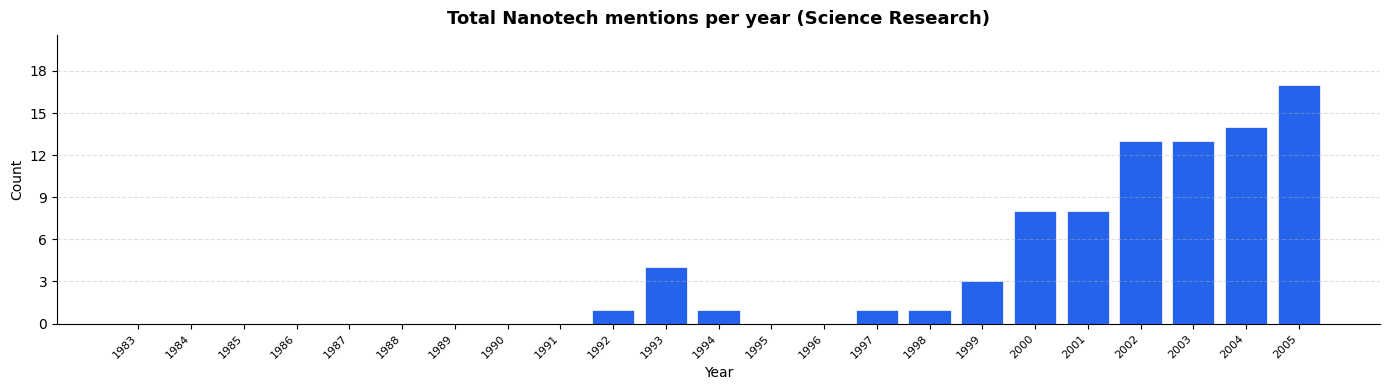

In [29]:
nano_sum = df.groupby('Year')['Nanotech'].sum().reindex(all_years, fill_value=0)

fig, ax = plt.subplots(figsize=(14, 4))
make_bar(ax, all_years, nano_sum.values, '#2563EB',
         'Total Nanotech mentions per year (Science Research)',
         is_percent=False)   # raw count — no % axis
plt.tight_layout()
plt.show()

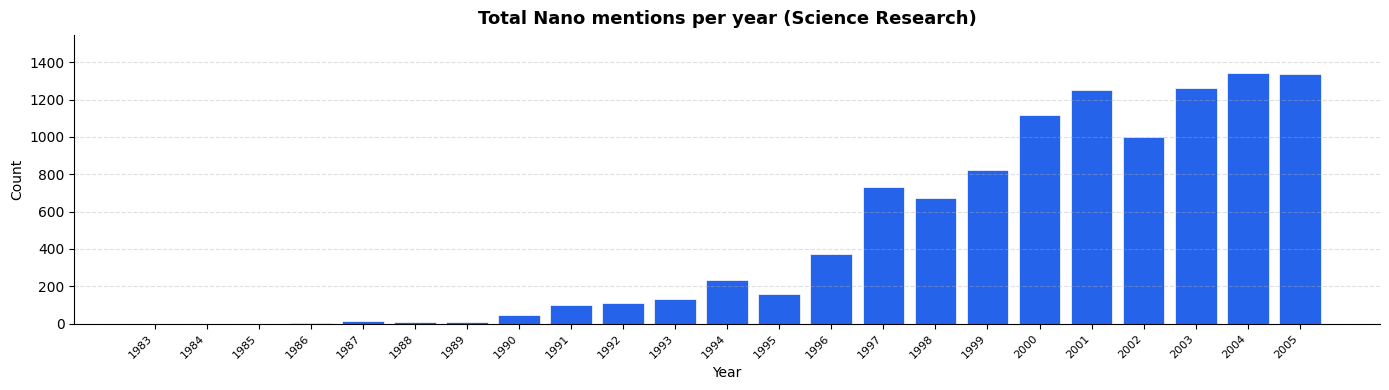

In [30]:
nano_sum = df.groupby('Year')['Nano'].sum().reindex(all_years, fill_value=0)

fig, ax = plt.subplots(figsize=(14, 4))
make_bar(ax, all_years, nano_sum.values, '#2563EB',
         'Total Nano mentions per year (Science Research)',
         is_percent=False)   # raw count — no % axis
plt.tight_layout()
plt.show()

## 2 — % of articles with Nanotech ≥ 1 (any nano mention)

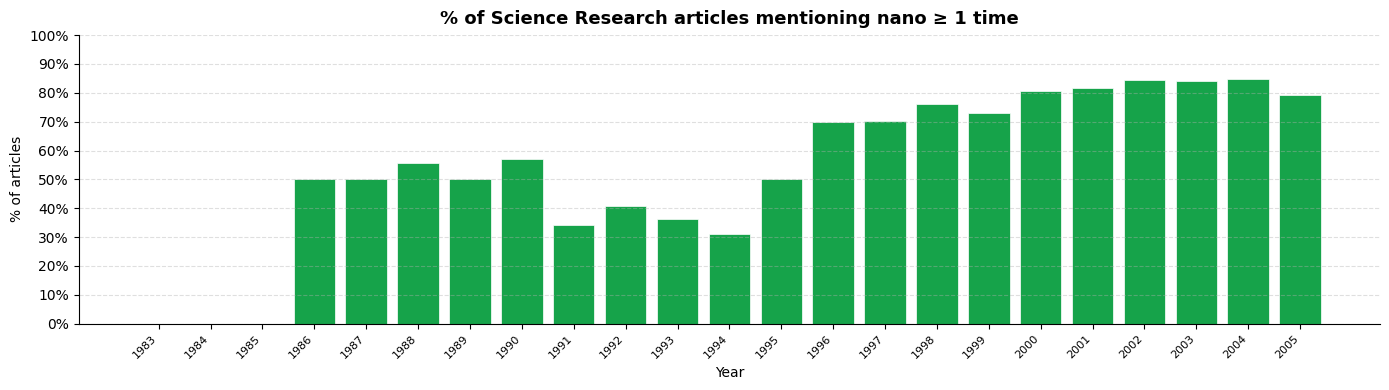

In [31]:
pct_nano_yes = pct_per_year(df['Nano'] >= 1)

fig, ax = plt.subplots(figsize=(14, 4))
make_bar(ax, all_years, pct_nano_yes.values, '#16A34A',
         '% of Science Research articles mentioning nano ≥ 1 time')
plt.tight_layout()
plt.show()

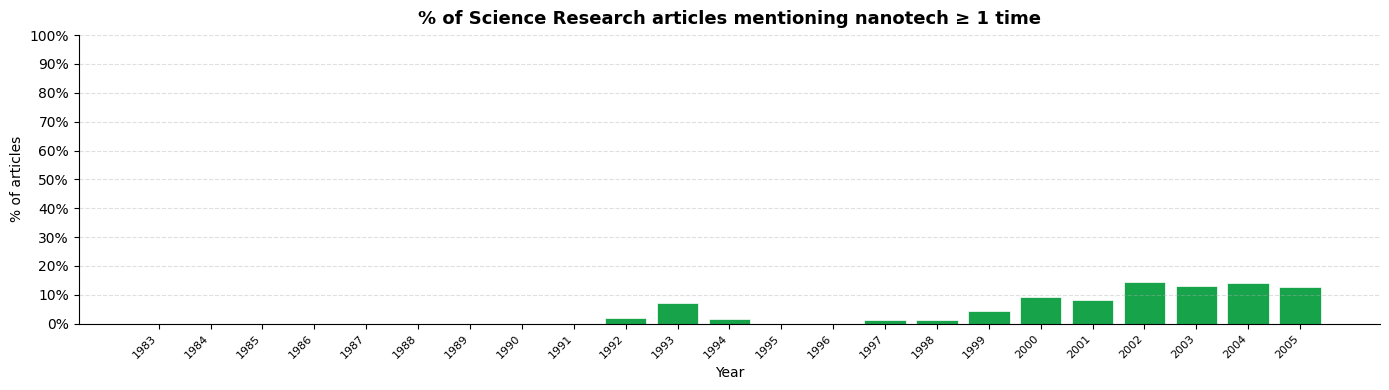

In [32]:
pct_nano_yes = pct_per_year(df['Nanotech'] >= 1)

fig, ax = plt.subplots(figsize=(14, 4))
make_bar(ax, all_years, pct_nano_yes.values, '#16A34A',
         '% of Science Research articles mentioning nanotech ≥ 1 time')
plt.tight_layout()
plt.show()

## 3 — % of articles with zero nano mentions

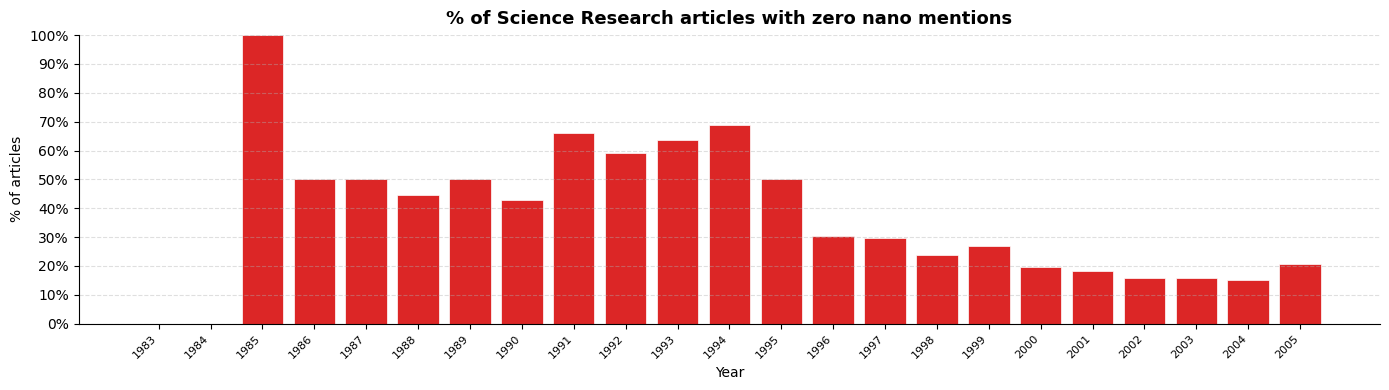

In [33]:
pct_nano_no = pct_per_year(df['Nano'] == 0)

fig, ax = plt.subplots(figsize=(14, 4))
make_bar(ax, all_years, pct_nano_no.values, '#DC2626',
         '% of Science Research articles with zero nano mentions')
plt.tight_layout()
plt.show()

## 4 — % of articles mentioning each keyword (one graph per keyword)

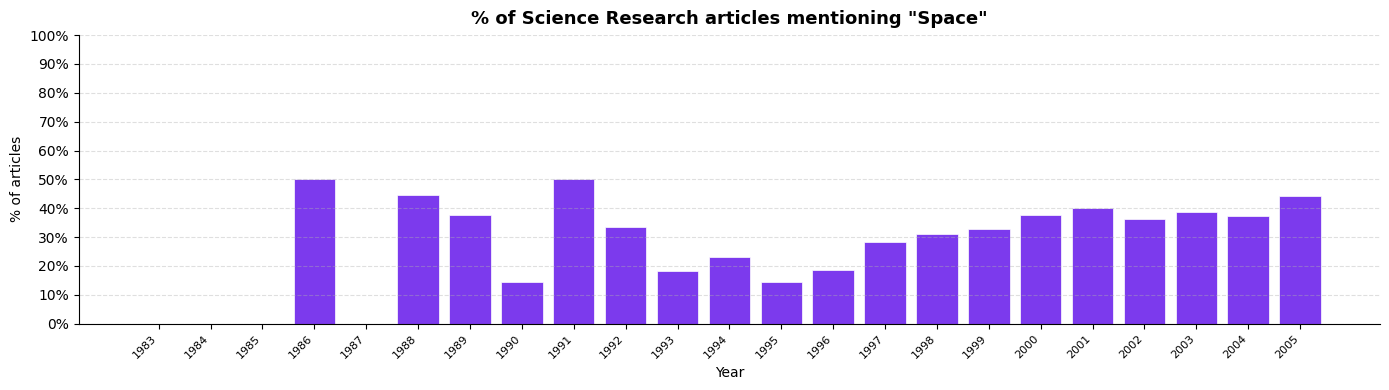

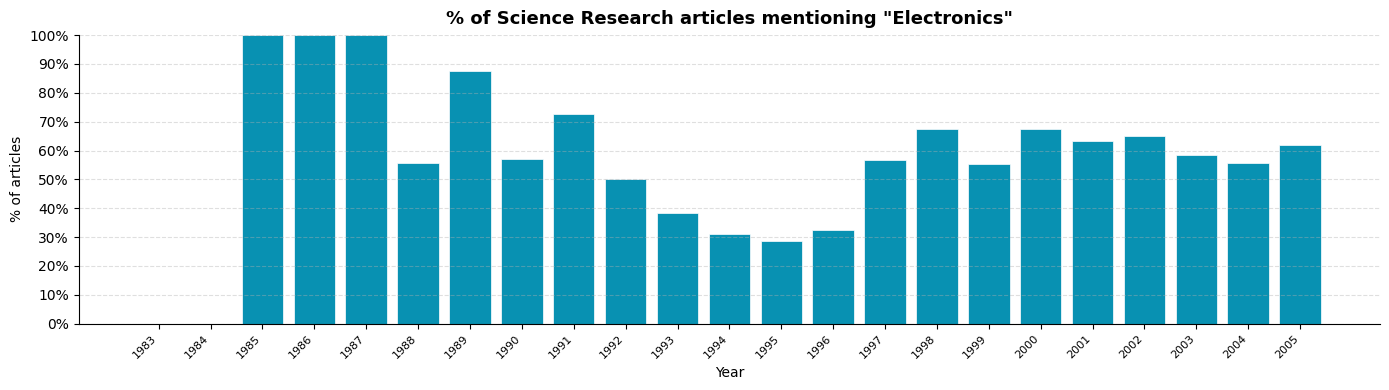

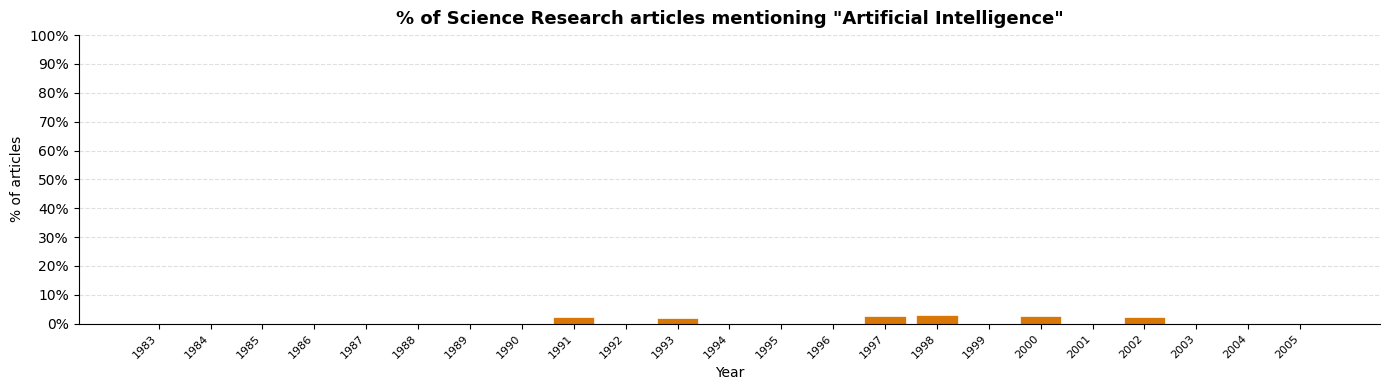

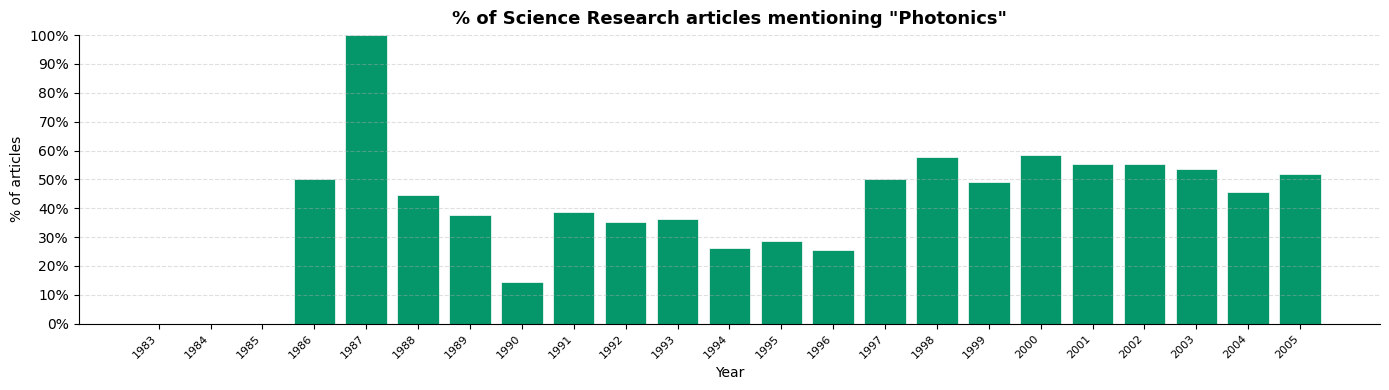

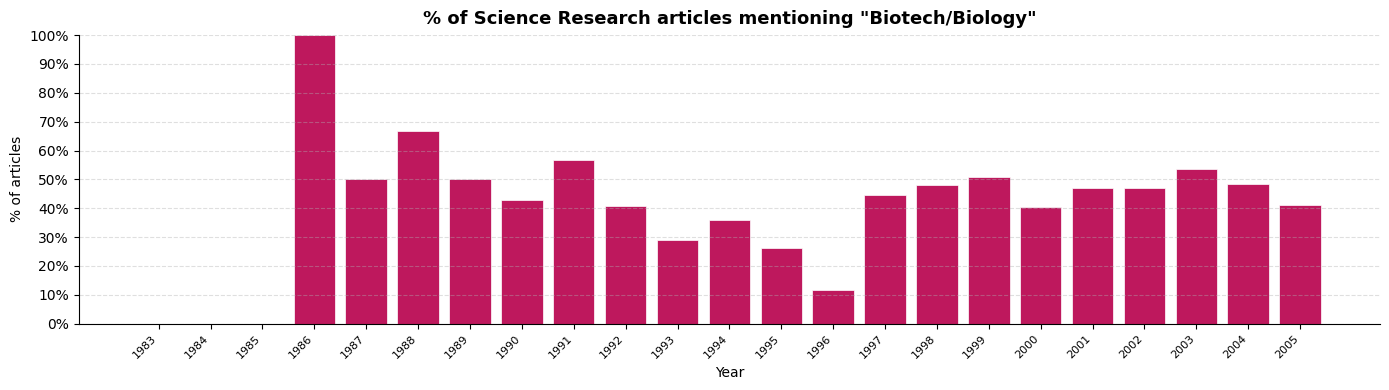

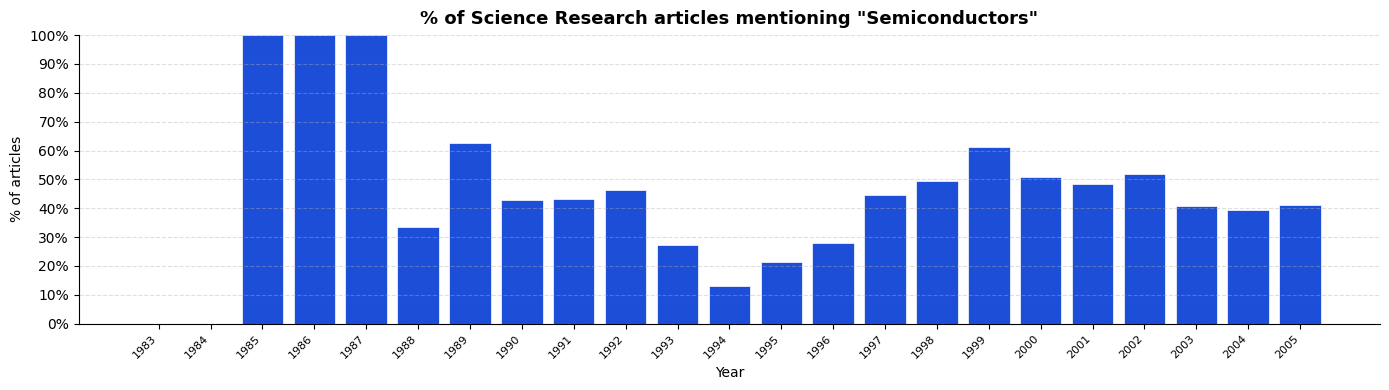

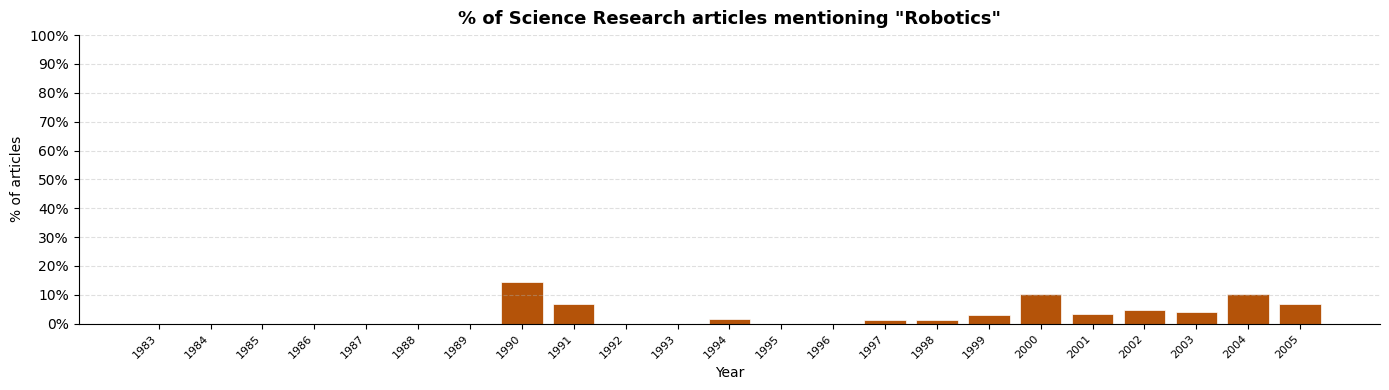

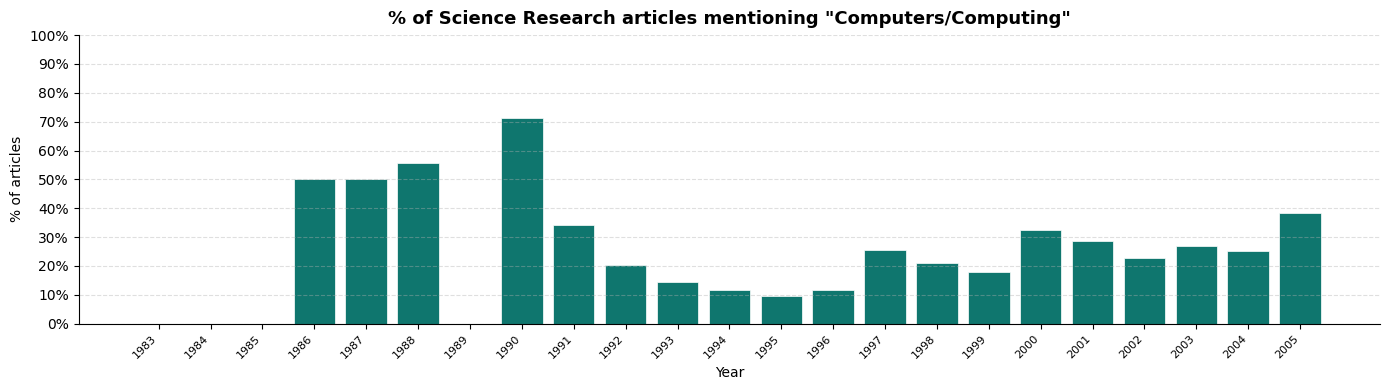

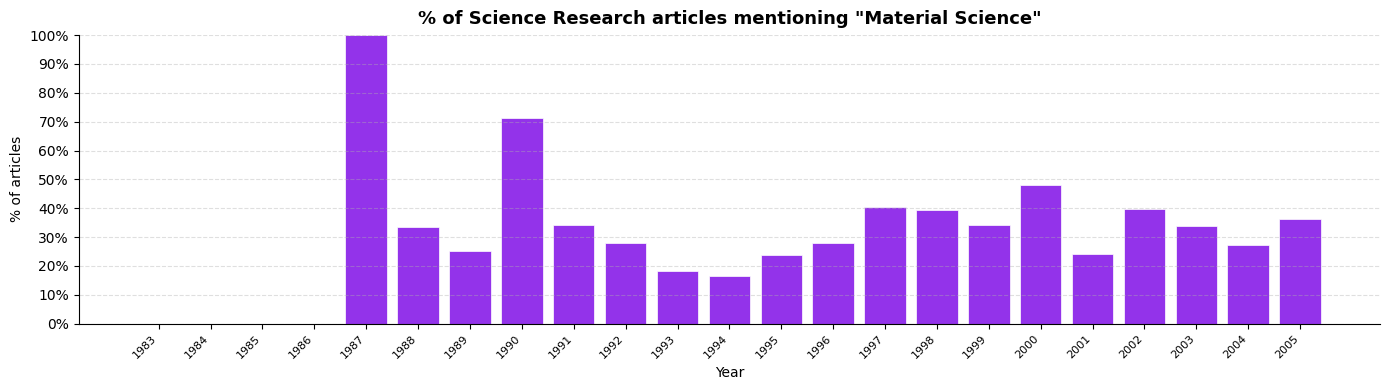

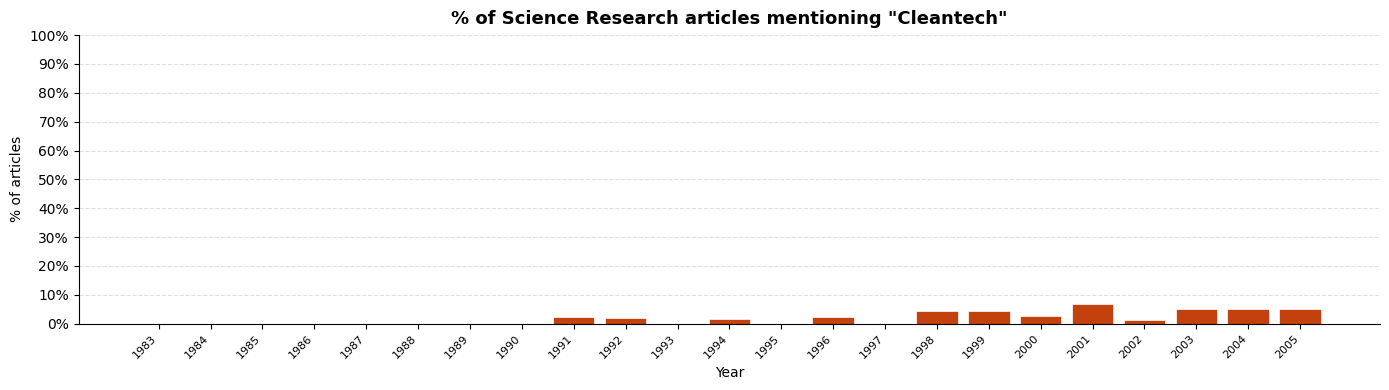

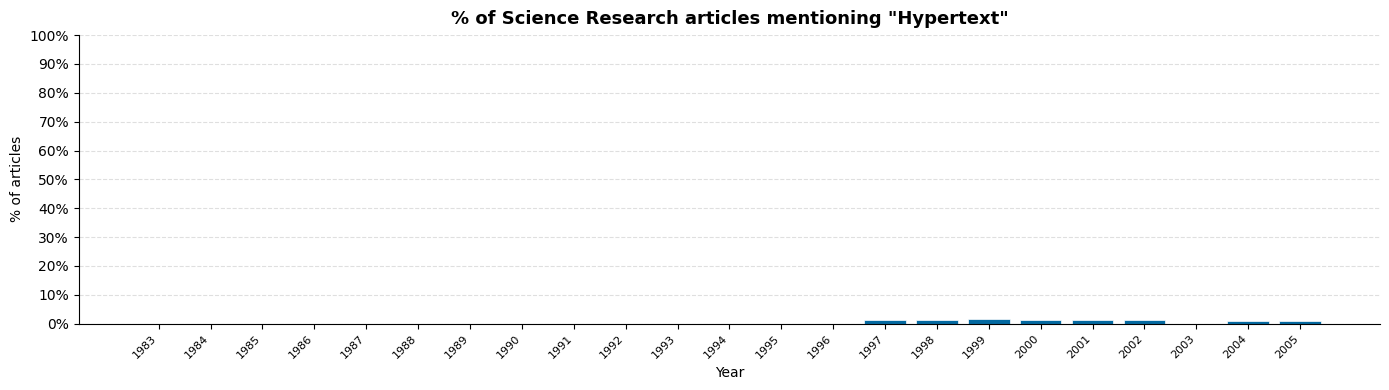

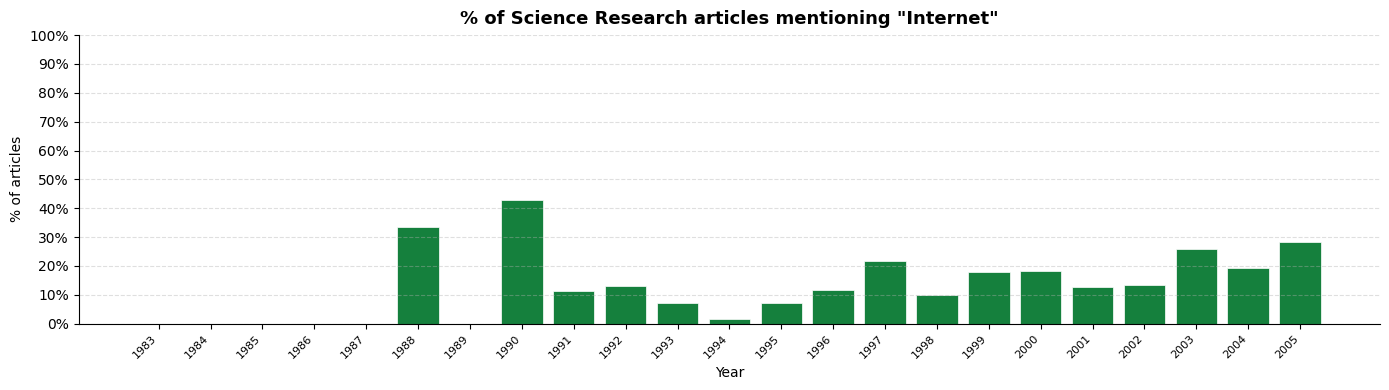

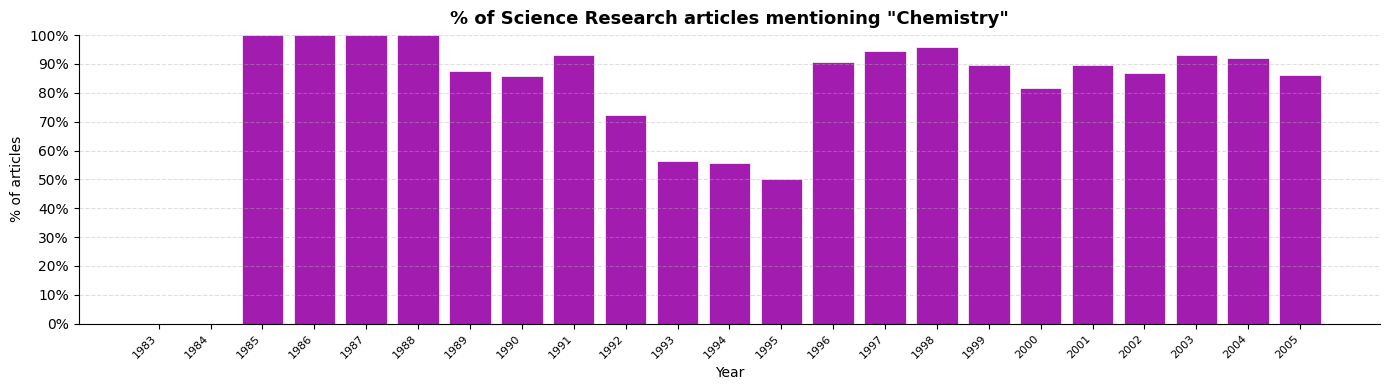

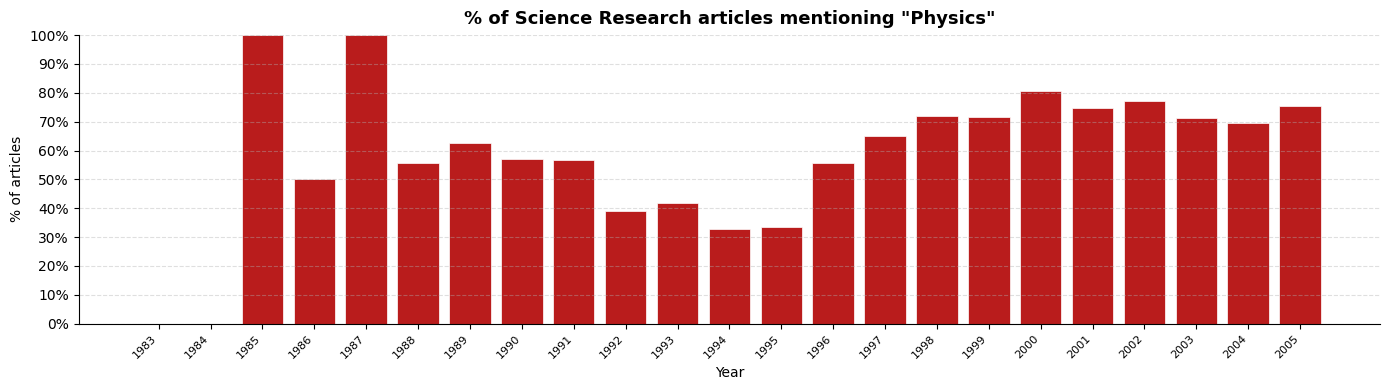

In [34]:
COLORS = [
    '#7C3AED','#0891B2','#D97706','#059669','#BE185D',
    '#1D4ED8','#B45309','#0F766E','#9333EA','#C2410C',
    '#0369A1','#15803D','#A21CAF','#B91C1C'
]

for i, col in enumerate(KEYWORD_COLS):
    if col not in df.columns:
        print(f"Column '{col}' not found — skipping")
        continue

    pct = pct_per_year_from_col(col)
    fig, ax = plt.subplots(figsize=(14, 4))
    make_bar(ax, all_years, pct.values, COLORS[i % len(COLORS)],
             f'% of Science Research articles mentioning "{col}"')
    plt.tight_layout()
    safe_name = col.lower().replace('/', '_').replace(' ', '_')
    plt.show()

## 5 — Overview: all keywords side-by-side (small multiples)

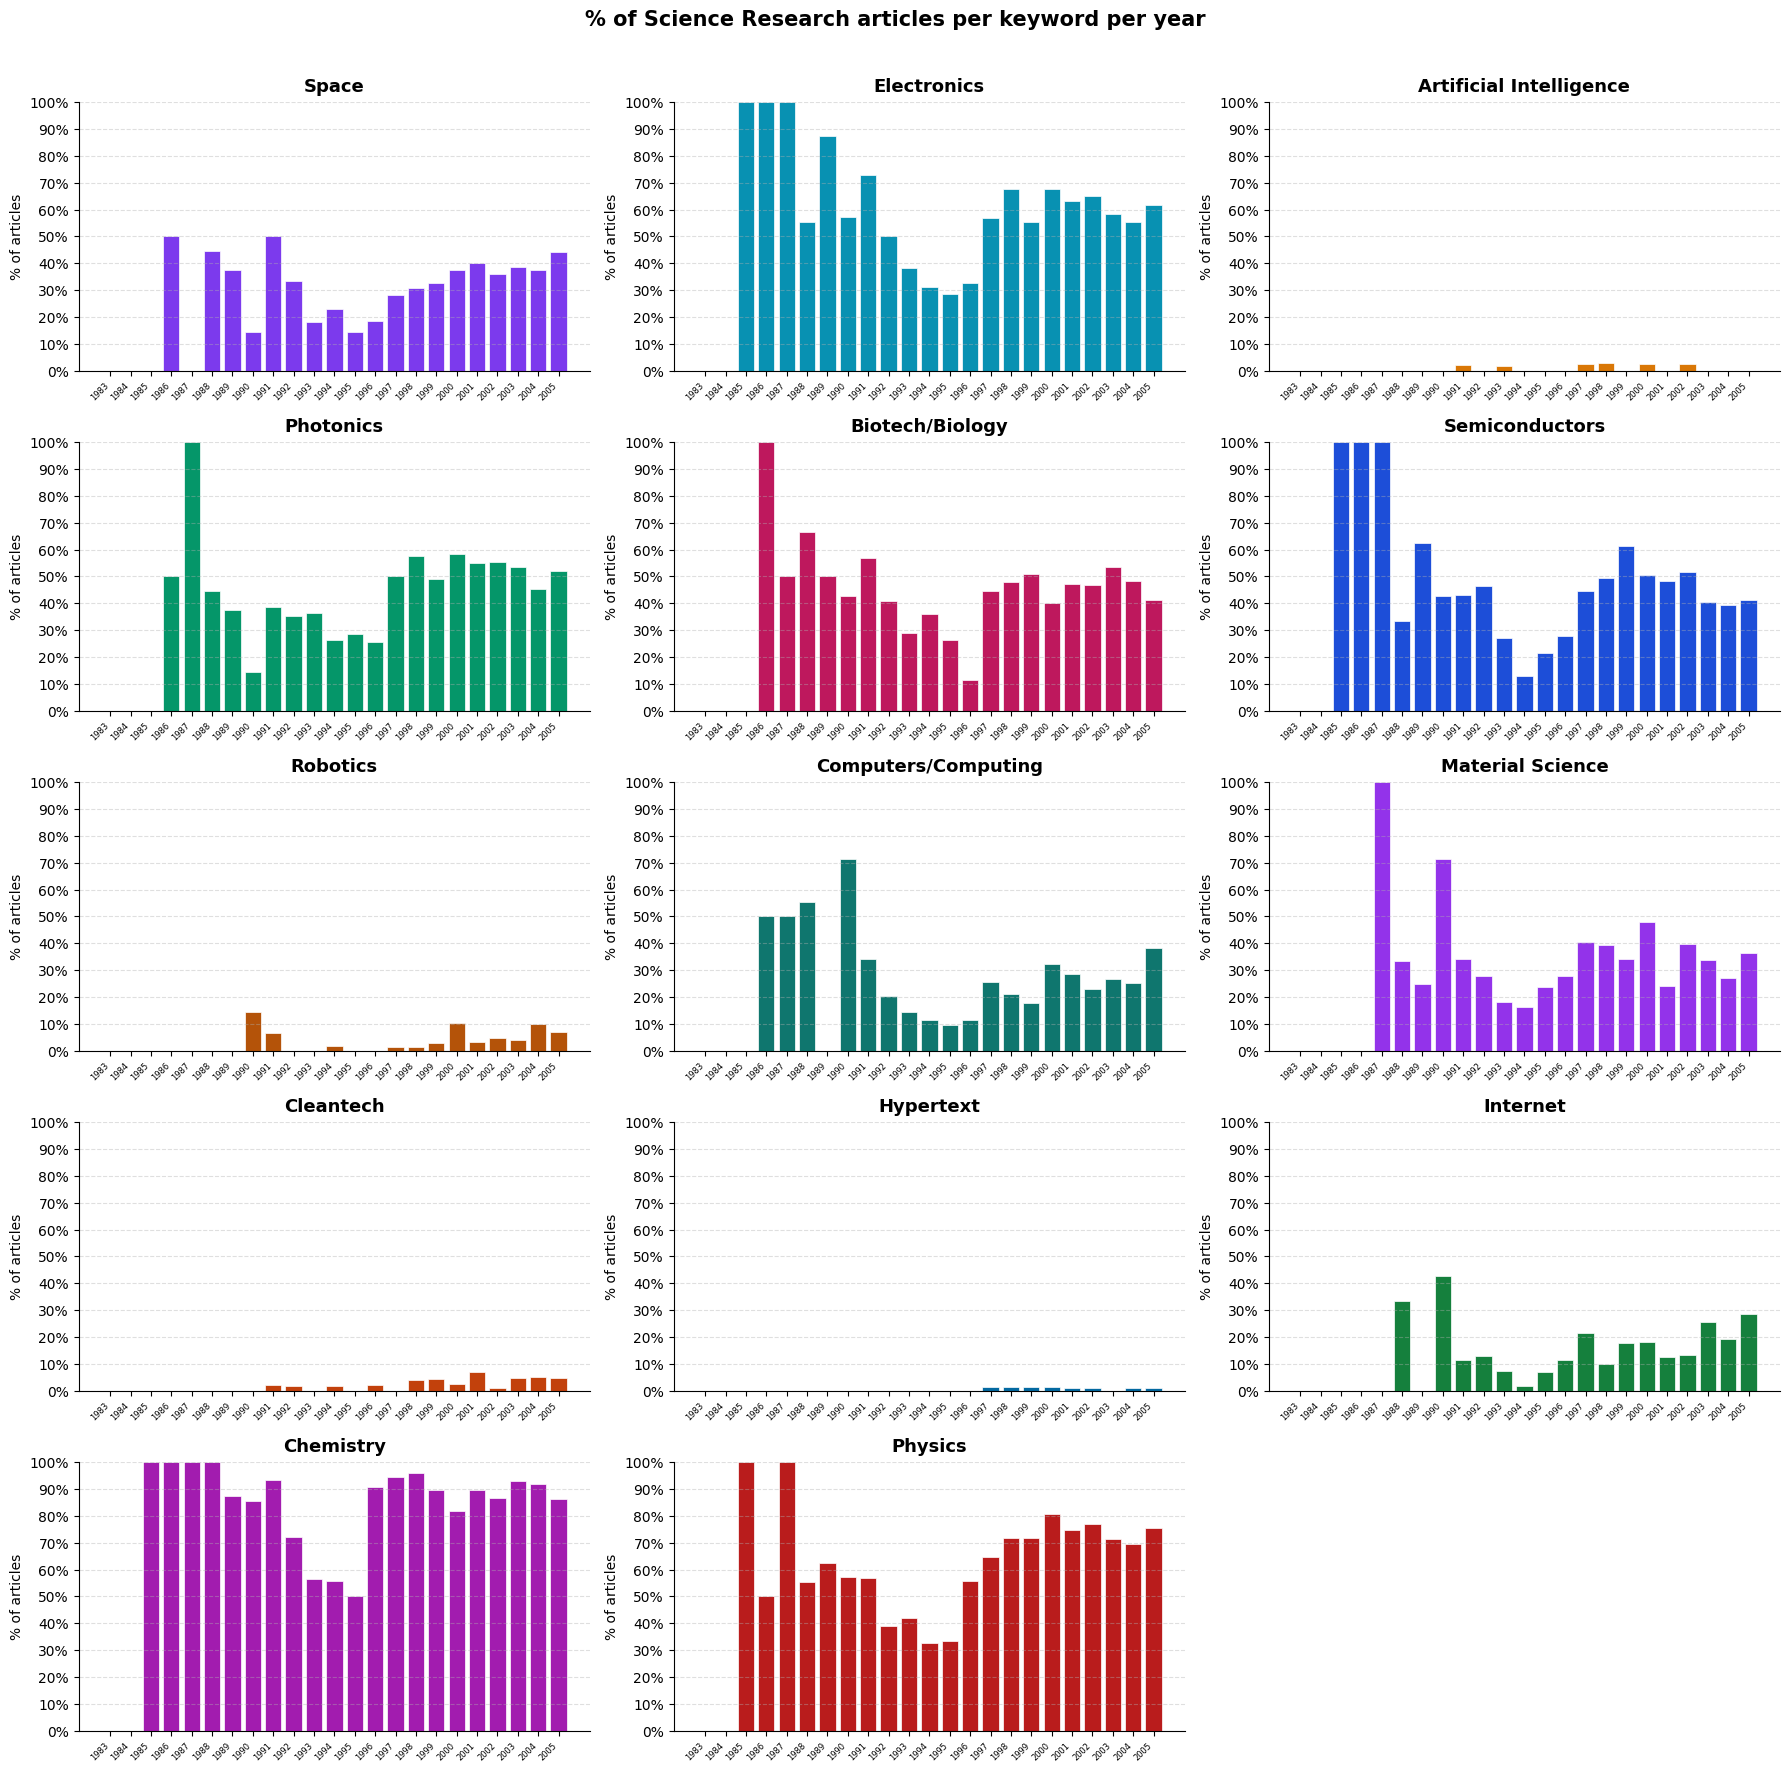

In [35]:
valid_cols = [c for c in KEYWORD_COLS if c in df.columns]
ncols = 3
nrows = -(-len(valid_cols) // ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 3.5))
axes = axes.flatten()

for i, col in enumerate(valid_cols):
    pct = pct_per_year_from_col(col)
    make_bar(axes[i], all_years, pct.values, COLORS[i % len(COLORS)], col)
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', labelsize=6)

for j in range(len(valid_cols), len(axes)):
    axes[j].set_visible(False)

fig.suptitle('% of Science Research articles per keyword per year',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()